### Crop Yield Prediction

Import packages

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns

Load Dataset

In [2]:
crop_train_pd = pd.read_csv('crop_yield_train.csv')

In [4]:
print(f"Columns: {crop_train_pd.columns.values}")

Columns: ['id' 'soil_ph' 'soil_moisture' 'avg_temperature' 'total_rainfall'
 'fertilizer_amount' 'pesticide_usage' 'sunlight_hours' 'nitrogen_content'
 'phosphorus_content' 'potassium_content' 'irrigation_frequency'
 'crop_type' 'region' 'season' 'harvest_date' 'field_id' 'yield_tpha']


'N' means column in numeric, 'C' means column is categoric <br>

id: ID of the area of land <br>
soil_ph: pH level of soil, from 0 to 14 where 0-7 is acid and 7-14 is alkali (N) <br>
soil_moisture: amount of water in soil, expressed as a percentage or a ratio (N) <br>
avg_temperature: temperature in celsius (N) <br>
total_rainfaill: total rainfall in millimeters (N) <br>
fertilizer_amount: amount of fertilizer used in kg / pounds (N) <br>
pesticide_usage: amount of pesticide used in kg / pounds (N) <br>
sunlight_hours: hours of sunlight on the crop in a year (N) <br>
nitrogen_content: amount of nitrogen in soil (N) <br>
phosphorus_content: amount of phosphorus in soil (N) <br>
potassium_content: amount of potassium in soil (N) <br>
irrigation_frequency: gap in days between watering of soil (N) <br>
crop_type: type of crop (C) <br>
region: region of crop (C) <br>
season: season crop was planted / harvested? (C) <br>
harvest_date: date crop was harvested (date) <br>
field_id: Feild ID <br>
yield_tpha: Yield in tons per hectare (C) <br>

In [5]:
crop_train_pd.head()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id,yield_tpha
0,0,7.831719,37.192725,32.270297,145.627849,124.830027,11.132490,1911.116978,1.445159,0.698938,1.074339,3,Soybean,South,Autumn,2021-03-09,F0138,3.790277
1,1,6.685905,23.715684,25.852201,599.005355,120.168428,11.846171,2011.488102,0.525983,1.137722,1.718454,3,Soybean,South,Spring,2021-07-18,F0393,5.660778
2,2,8.338307,20.481400,18.202587,333.247698,270.799112,10.588497,1929.725597,2.996184,1.079680,1.386601,5,Soybean,North,Summer,2021-11-20,F0066,7.098251
3,3,7.214680,42.446504,13.758647,523.610747,99.013588,1.222238,2231.228584,2.680929,0.764238,0.814746,5,Corn,East,Summer,2021-03-02,F0150,5.461535
4,4,5.129093,16.614817,14.444958,1005.931705,169.955045,6.350100,2826.831668,1.298629,1.487599,0.910354,3,Corn,Central,Summer,2021-10-24,F0498,6.336988


## Dataset Column-wise statistics

Numeric Columns

In [6]:
crop_train_pd.describe()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,yield_tpha
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.00000,4800.000000
mean,2399.500000,6.488921,29.773509,22.611837,664.899520,174.118162,7.503675,1998.422659,1.743984,0.849754,1.259443,3.51750,6.266544
std,1385.784976,1.157450,11.450575,7.216816,317.139245,71.013714,4.321436,580.119404,0.725161,0.374612,0.431053,1.70021,1.152830
min,0.000000,4.500123,10.006310,10.006311,100.052936,50.048716,0.000083,1001.189516,0.500042,0.200136,0.500013,1.00000,2.336034
25%,1199.750000,5.486213,19.946112,16.366475,397.722256,114.161062,3.704181,1501.017794,1.102405,0.523522,0.893486,2.00000,5.456201
50%,2399.500000,6.498052,29.458503,22.751940,663.965012,174.802816,7.534955,1993.580169,1.742928,0.858752,1.266509,4.00000,6.300939
75%,3599.250000,7.469106,39.664469,28.930034,938.935865,233.623204,11.224521,2510.739520,2.376288,1.167919,1.635346,5.00000,7.080690
max,4799.000000,8.498871,49.986928,34.995129,1199.891075,299.933021,14.996841,2998.537370,2.999930,1.499794,1.999910,6.00000,9.539713


All row values are filled, no missing values <br>
All soil pH fall between 4.5 - 8.5 <br>
Temperatures fall between 10 C - 35 C <br>
Some fields have no pesticide usage <br>
All fields have atleast some nitrogen, phosphorus and potassium content <br>
Irrigation frequency fall between 1-6 days
Yield (tpha) fall between 2.33 - 9.54


Cateogorical Columns

In [8]:
crop_train_pd.describe(include=['O'])

,crop_type,region,season,harvest_date,field_id
count,4800,4800,4800,4800,4800
unique,5,5,3,365,498
top,Wheat,North,Spring,2021-05-05,F0143
freq,986,985,1643,26,20


In [14]:
print(f"{crop_train_pd['crop_type'].nunique()} unique crop_type values: {crop_train_pd['crop_type'].unique()}")
print(f"{crop_train_pd['region'].nunique()} unique region values: {crop_train_pd['region'].unique()}")
print(f"{crop_train_pd['season'].nunique()} unique season values: {crop_train_pd['season'].unique()}")
print(f"{crop_train_pd['field_id'].nunique()} unique field_id values")

5 unique crop_type values: ['Soybean' 'Corn' 'Barley' 'Wheat' 'Rice']
5 unique region values: ['South' 'North' 'East' 'Central' 'West']
3 unique season values: ['Autumn' 'Spring' 'Summer']
498 unique field_id values


There are only 498 unique fields, however 4800 ids, which mean some of these crops are grown on the same field / land

## No. of fields per dimension Analysis

In [ ]:
fields_per_crop = crop_train_pd.groupby('crop_type')['field_id'].nunique()
print(fields_per_crop)

crop_type
Barley     427
Corn       431
Rice       413
Soybean    417
Wheat      432
Name: field_id, dtype: int64


In [17]:
fields_per_season = crop_train_pd.groupby('season')['field_id'].nunique()
print(fields_per_season)

season
Autumn    475
Spring    478
Summer    481
Name: field_id, dtype: int64


In [18]:
fields_per_region = crop_train_pd.groupby('region')['field_id'].nunique()
print(fields_per_region)

region
Central    438
East       421
North      424
South      428
West       427
Name: field_id, dtype: int64


In [20]:
def unique_list_agg(series):
    return list(set(series))

fields_per_region_list_pd = crop_train_pd.groupby('field_id')['region'].agg(unique_list_agg)
print(fields_per_region_list_pd)

field_id
F0001    [West, South, East, Central, North]
F0002                          [North, West]
F0003    [West, South, East, Central, North]
F0004    [West, South, East, Central, North]
F0005    [West, South, East, Central, North]
                        ...                 
F0494    [West, South, East, Central, North]
F0495    [West, South, East, Central, North]
F0497    [West, South, East, Central, North]
F0498    [West, South, East, Central, North]
F0499                          [North, West]
Name: region, Length: 498, dtype: object


In [22]:
crop_train_pd[crop_train_pd['field_id'] == 'F0002'].head(10)

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id,yield_tpha
165,165,5.538306,25.037535,31.084791,721.821650,109.222923,12.820172,2947.995466,0.555350,0.879982,1.145372,3,Rice,North,Summer,2021-08-28,F0002,5.282829
680,680,5.384955,36.450612,11.823997,370.493347,94.126102,1.873639,1622.786362,0.618021,1.447691,1.267386,3,Soybean,West,Summer,2021-05-30,F0002,5.495996
683,683,7.389010,28.136649,33.110752,957.437181,165.174753,10.616450,2661.133563,2.284468,0.915269,1.689071,3,Soybean,West,Spring,2021-12-09,F0002,5.961497
1641,1641,6.008807,46.618920,23.096390,903.946905,185.259787,1.802137,1487.713539,1.415029,1.352492,1.118642,4,Rice,West,Summer,2021-08-22,F0002,6.461800
1956,1956,7.973638,23.978965,30.257578,288.234664,124.715540,6.939588,2189.176624,0.833500,0.359118,0.533661,4,Corn,West,Spring,2021-04-18,F0002,4.624910
4294,4294,6.787984,24.945633,10.110040,941.099594,236.469886,8.001005,1597.824082,1.518911,0.273715,1.453362,2,Soybean,West,Spring,2021-06-21,F0002,7.396080


In [27]:
crop_train_pd['harvest_date_dt'] = pd.to_datetime(crop_train_pd['harvest_date'], format='%Y-%m-%d')
min_date = crop_train_pd['harvest_date_dt'].min()
max_date = crop_train_pd['harvest_date_dt'].max()
print(f"Date range: {min_date} to {max_date}")

Date range: 2021-01-01 00:00:00 to 2021-12-31 00:00:00


## Correlation of Yield and Dimension

In [32]:
crop_train_pd[['season', 'yield_tpha']].groupby(['season'], as_index=False).mean().sort_values(by='yield_tpha', ascending=False)

,season,yield_tpha
2,Summer,6.286842
1,Spring,6.274553
0,Autumn,6.236848


In [31]:
crop_train_pd[['crop_type', 'yield_tpha']].groupby(['crop_type'], as_index=False).mean().sort_values(by='yield_tpha', ascending=False)

,crop_type,yield_tpha
0,Barley,6.284633
3,Soybean,6.275141
4,Wheat,6.266751
2,Rice,6.254912
1,Corn,6.251237


In [33]:
crop_train_pd[['crop_type', 'season', 'yield_tpha']].groupby(['crop_type','season'], as_index=False).mean().sort_values(by='yield_tpha', ascending=False)

,crop_type,season,yield_tpha
10,Soybean,Spring,6.355952
7,Rice,Spring,6.345006
5,Corn,Summer,6.337140
14,Wheat,Summer,6.336153
2,Barley,Summer,6.317789
0,Barley,Autumn,6.294075
13,Wheat,Spring,6.270562
3,Corn,Autumn,6.253495
9,Soybean,Autumn,6.246208
1,Barley,Spring,6.243221


Harvest Date vs Yield

In [36]:
crop_train_pd.head()

,id,soil_ph,soil_moisture,avg_temperature,total_rainfall,fertilizer_amount,pesticide_usage,sunlight_hours,nitrogen_content,phosphorus_content,potassium_content,irrigation_frequency,crop_type,region,season,harvest_date,field_id,yield_tpha,harvest_date_dt
0,0,7.831719,37.192725,32.270297,145.627849,124.830027,11.132490,1911.116978,1.445159,0.698938,1.074339,3,Soybean,South,Autumn,2021-03-09,F0138,3.790277,2021-03-09
1,1,6.685905,23.715684,25.852201,599.005355,120.168428,11.846171,2011.488102,0.525983,1.137722,1.718454,3,Soybean,South,Spring,2021-07-18,F0393,5.660778,2021-07-18
2,2,8.338307,20.481400,18.202587,333.247698,270.799112,10.588497,1929.725597,2.996184,1.079680,1.386601,5,Soybean,North,Summer,2021-11-20,F0066,7.098251,2021-11-20
3,3,7.214680,42.446504,13.758647,523.610747,99.013588,1.222238,2231.228584,2.680929,0.764238,0.814746,5,Corn,East,Summer,2021-03-02,F0150,5.461535,2021-03-02
4,4,5.129093,16.614817,14.444958,1005.931705,169.955045,6.350100,2826.831668,1.298629,1.487599,0.910354,3,Corn,Central,Summer,2021-10-24,F0498,6.336988,2021-10-24


Generating charts in a 2x3 grid.


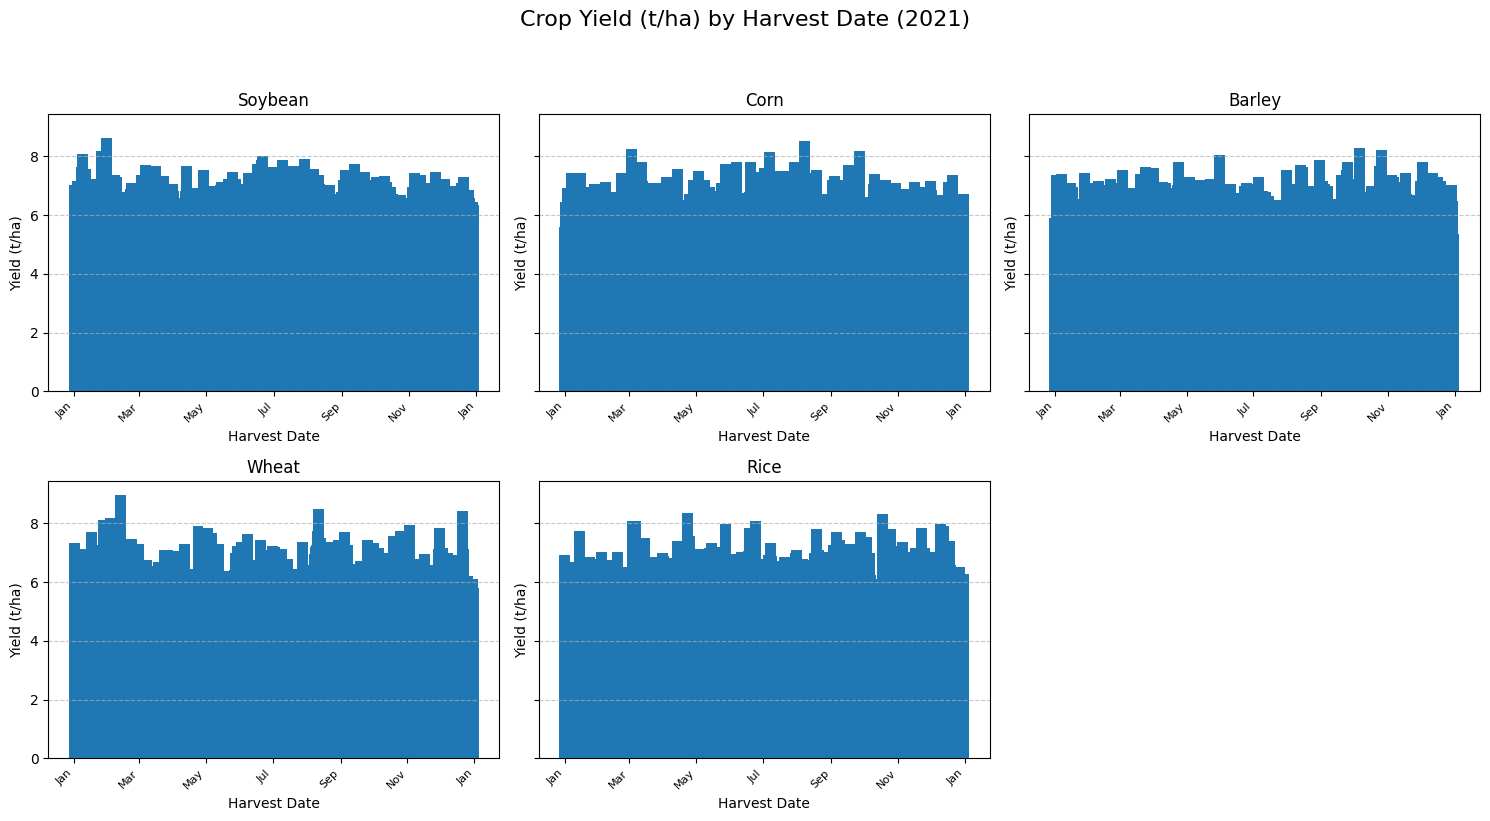

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_all_yield_charts_in_grid(dataframe):
    """
    Generates a single figure containing all crop yield charts arranged in a grid.

    Args:
        dataframe (pd.DataFrame): The input DataFrame with 'harvest_date_dt', 
                                  'yield_tpha', and 'crop_type' columns.
    
    Returns:
        plt.Figure: The single Matplotlib Figure object containing all subplots.
    """
    unique_crops = dataframe['crop_type'].unique()
    num_crops = len(unique_crops)
    
    # Determine the grid layout (e.g., 2 rows, 3 columns for 5 crops)
    # This example uses 2 rows for 5 crops: 3 in the top row, 2 in the bottom
    num_cols = 3
    num_rows = int(np.ceil(num_crops / num_cols))
    
    # 1. Create the single large figure
    # Adjust figsize based on the number of rows and columns
    fig, axes = plt.subplots(num_rows, num_cols, 
                             figsize=(5 * num_cols, 4 * num_rows), 
                             sharey=True)
    
    # Flatten the axes array for easy iteration (important if num_rows > 1)
    if num_rows > 1:
        axes = axes.flatten()
    elif num_rows == 1:
        # Ensure it's iterable even if it's a single row
        axes = np.array([axes]).flatten()
    
    print(f"Generating charts in a {num_rows}x{num_cols} grid.")

    # 2. Loop through each crop type and plot on its dedicated subplot (axis)
    for i, crop in enumerate(unique_crops):
        ax = axes[i] # Get the specific axis for the current crop
        
        # Filter and Aggregate Data
        df_crop = dataframe[dataframe['crop_type'] == crop].copy()
        df_plot = df_crop.groupby('harvest_date_dt')['yield_tpha'].mean().reset_index()

        # Plot the bar chart
        ax.bar(df_plot['harvest_date_dt'], df_plot['yield_tpha'], width=10)
        
        # Format the subplot
        ax.set_title(f'{crop}', fontsize=12)
        ax.set_xlabel('Harvest Date', fontsize=10)
        ax.set_ylabel('Yield (t/ha)', fontsize=10)
        
        # Improve x-axis date display
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Show just the month
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Clean up any unused subplots (if, for example, 5 plots in a 6-slot grid)
    for j in range(num_crops, num_rows * num_cols):
        fig.delaxes(axes[j])
        
    # 4. Final layout adjustments for the entire figure
    fig.suptitle('Crop Yield (t/ha) by Harvest Date (2021)', fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make room for suptitle
    
    # Return the single figure object
    return fig

# --- How to use this function ---
# Assuming 'df' is your pandas DataFrame:
combined_figure = plot_all_yield_charts_in_grid(crop_train_pd)

# # To display the combined figure:
# # plt.show()

Generating charts in a 5x3 grid (Total 15 charts)...


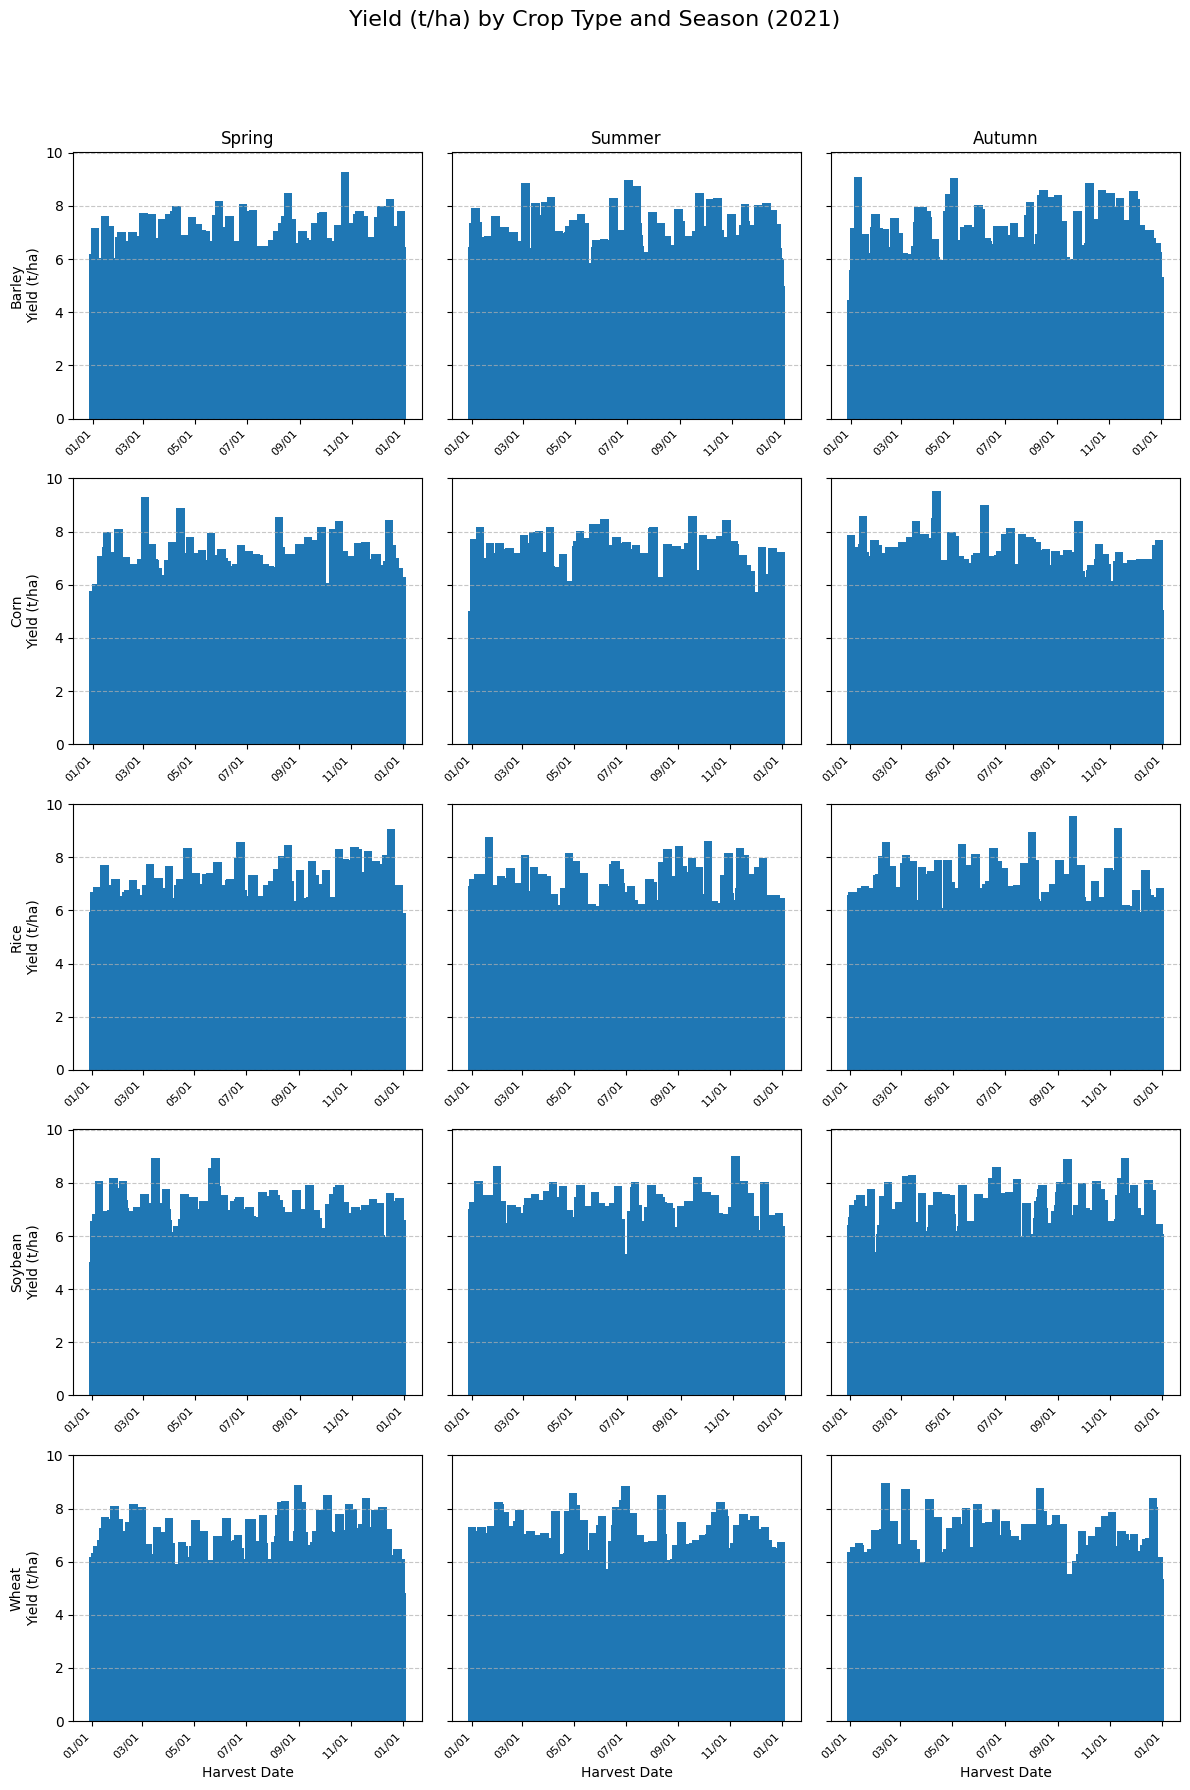

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_yield_by_crop_and_season_existing_col(dataframe):
    """
    Generates a single figure with 5 rows (crop types) and 3 columns (seasons)
    of bar charts plotting yield_tpha vs harvest_date_dt, using the existing 
    'season' column for grouping.

    Args:
        dataframe (pd.DataFrame): The input DataFrame with 'harvest_date_dt', 
                                  'yield_tpha', 'crop_type', and 'season' columns.
                                  
    Returns:
        plt.Figure: The single Matplotlib Figure object containing all subplots.
    """
    
    # 1. Define Categories and Grid Structure
    # Use unique values from the existing columns
    unique_crops = sorted(dataframe['crop_type'].unique().tolist())
    # Use the seasons from the data, sorted for consistent column order
    # Assuming 'Spring', 'Summer', 'Autumn' are the only values and are desired in that order
    season_order = ['Spring', 'Summer', 'Autumn']
    
    num_rows = len(unique_crops)
    num_cols = len(season_order)
    
    # 2. Create the single large figure with 5x3 subplots
    # sharey=True ensures all plots have the same y-axis scale for easy comparison
    fig, axes = plt.subplots(num_rows, num_cols, 
                             figsize=(4 * num_cols, 3.5 * num_rows), 
                             sharey=True)
    
    # Ensure axes is a 2D array for consistent iteration
    if num_rows == 1 or num_cols == 1:
        axes = axes.reshape(num_rows, num_cols)
        
    print(f"Generating charts in a {num_rows}x{num_cols} grid (Total {num_rows * num_cols} charts)...")

    # 3. Iterate through the grid: Crops (rows) and Seasons (columns)
    for i, crop in enumerate(unique_crops):
        for j, season in enumerate(season_order):
            ax = axes[i, j] # Select the specific axis for (crop, season)
            
            # Filter Data: Use the existing 'crop_type' and 'season' columns
            df_plot_filter = dataframe[
                (dataframe['crop_type'] == crop) & 
                (dataframe['season'] == season)
            ]
            
            # Aggregate by date (mean yield)
            df_plot = df_plot_filter.groupby('harvest_date_dt')['yield_tpha'].mean().reset_index()

            # Plot the bar chart
            if not df_plot.empty:
                # Use a fixed bar width (e.g., 10 days) for visual consistency
                ax.bar(df_plot['harvest_date_dt'], df_plot['yield_tpha'], width=10)
            
            # --- Formatting ---
            
            # Column headers (Season names) for the first row
            if i == 0:
                ax.set_title(f'{season}', fontsize=12)
            
            # Row headers (Crop names) and Y-axis label for the first column
            if j == 0:
                # Add crop name to the side of the row
                ax.set_ylabel(f'{crop}\nYield (t/ha)', fontsize=10)
            
            # X-axis label only for the bottom row
            if i == num_rows - 1:
                ax.set_xlabel('Harvest Date', fontsize=10)
            
            # Improve x-axis date display
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
            
            ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 4. Final layout adjustments for the entire figure
    fig.suptitle('Yield (t/ha) by Crop Type and Season (2021)', fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    # Returns the single figure object containing all 15 subplots
    return fig

# --- How to use this function ---
# Assume 'df' is your pandas DataFrame with 'harvest_date_dt', 'yield_tpha', 'crop_type', and 'season'
# columns already populated.

combined_figure = plot_yield_by_crop_and_season_existing_col(crop_train_pd)

# # To display the combined figure:
# # plt.show()

From the plots above, its evident for a given crop, the mean yield per day does not change much depending on the season. There are no clear standouts, the effect of season on yield is not clearly visible.